# Projeto 02: Kaggle Competition
## Competição Escolhida

**Grupo:** H  
**Alunos:** Lucas de Oliveira Ferreira / Luis Enrique Asuncion Velasquez  
**Nome da competição:** What’s Cooking?
**Link da competição:** [What’s Cooking?](https://www.kaggle.com/competitions/whats-cooking)


# What’s Cooking Dataset

## Objetivo  
Prever a **cozinha (“cuisine”)** de uma receita a partir da lista de ingredientes.

## Descrição  
Este dataset é parte da competição *What’s Cooking* no Kaggle. Cada registro corresponde a uma receita, com sua lista de ingredientes e a cozinha correspondente (apenas no conjunto de treino).  
Você deve usar as informações de ingredientes para treinar modelos capazes de predizer corretamente a cozinha para novas receitas (test set).  

No conjunto de treino, cada receita possui um **id**, uma **cuisine** (etiqueta alvo) e uma lista de **ingredients** (strings). No conjunto de teste, há apenas `id` e `ingredients` — seu modelo deverá gerar a previsão de `cuisine`.

## Conteúdo do Dataset  
O dataset de treino contém **39.774 receitas** com **3 colunas**:  
- **id:** identificador único da receita  
- **cuisine:** tipo de cozinha (ex: “italian”, “mexican”, “indian” …)  
- **ingredients:** lista de ingredientes usados na receita (cada ingrediente é uma string)  

O dataset de teste contém **9.925 receitas** com as colunas **id** e **ingredients**, sem a coluna `cuisine`.  
O objetivo é construir um modelo que, dado os ingredientes, preveja qual é a cozinha da receita.


# Instalando e Importando Bibliotecas

In [ ]:
!pip install kagglehub gensim

In [ ]:
import kagglehub
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import difflib
from gensim.models import Word2Vec
import numpy as np
from scipy.sparse import hstack

# Importando Datasets

In [ ]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
path = kagglehub.competition_download("whats-cooking")

print("Arquivos disponíveis:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

100%|██████████| 2.20M/2.20M [00:00<00:00, 59.1MB/s]

Extracting files...
Arquivos disponíveis:
/root/.cache/kagglehub/competitions/whats-cooking/sample_submission.csv.zip
/root/.cache/kagglehub/competitions/whats-cooking/train.json.zip
/root/.cache/kagglehub/competitions/whats-cooking/test.json.zip


In [ ]:
extract_root = os.path.join(path, "unzipped")
os.makedirs(extract_root, exist_ok=True)

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".zip"):
            zip_path = os.path.join(root, file)
            print(f"Unzipping {zip_path} into {extract_root} ...")
            with zipfile.ZipFile(zip_path, "r") as z:
                z.extractall(extract_root)

Unzipping /root/.cache/kagglehub/competitions/whats-cooking/sample_submission.csv.zip into /root/.cache/kagglehub/competitions/whats-cooking/unzipped ...
Unzipping /root/.cache/kagglehub/competitions/whats-cooking/train.json.zip into /root/.cache/kagglehub/competitions/whats-cooking/unzipped ...
Unzipping /root/.cache/kagglehub/competitions/whats-cooking/test.json.zip into /root/.cache/kagglehub/competitions/whats-cooking/unzipped ...


In [ ]:
train_df = pd.read_json(os.path.join(extract_root, "train.json"))
test_df  = pd.read_json(os.path.join(extract_root, "test.json"))

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (39774, 3)
Test shape: (9944, 2)


# Análise dos Dados

In [ ]:
train_df.head()

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


In [ ]:
test_df.head()

,id,ingredients
0,18009,"[baking powder, eggs, all-purpose flour, raisi..."
1,28583,"[sugar, egg yolks, corn starch, cream of tarta..."
2,41580,"[sausage links, fennel bulb, fronds, olive oil..."
3,29752,"[meat cuts, file powder, smoked sausage, okra,..."
4,35687,"[ground black pepper, salt, sausage casings, l..."


O dataset não possui valores nulos que precisem de tratamento.

In [ ]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39774 entries, 0 to 39773
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           39774 non-null  int64 
 1   cuisine      39774 non-null  object
 2   ingredients  39774 non-null  object
dtypes: int64(1), object(2)
memory usage: 932.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9944 entries, 0 to 9943
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9944 non-null   int64 
 1   ingredients  9944 non-null   object
dtypes: int64(1), object(1)
memory usage: 155.5+ KB


O dataset possui 20 classes que apresentam desbalanceamento.

In [ ]:
train_df['cuisine'].nunique()

20

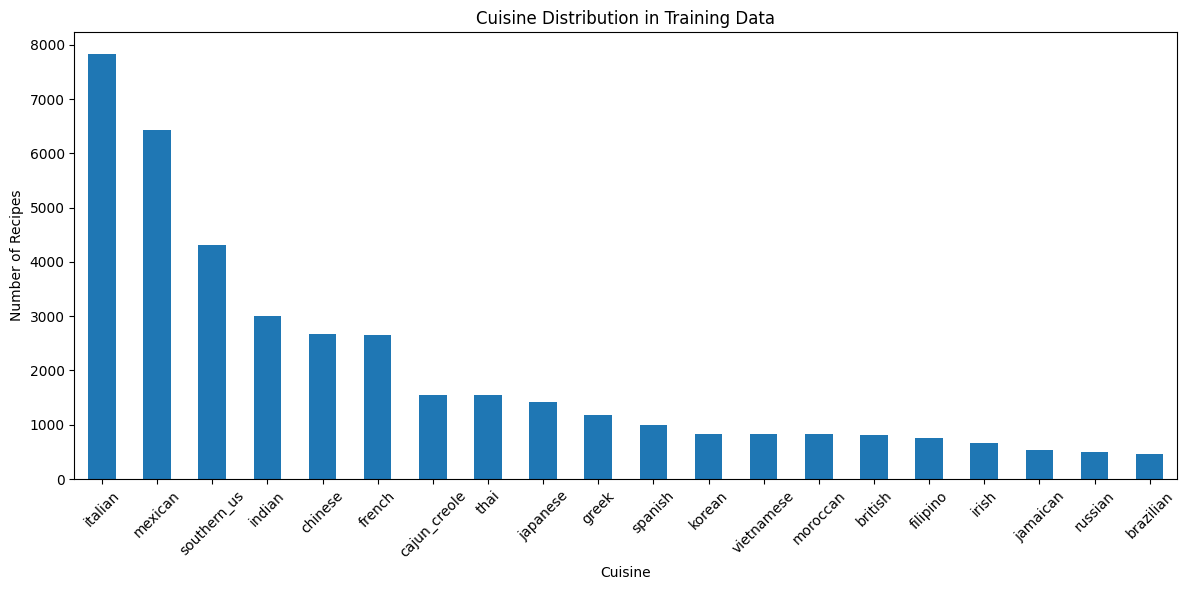

In [ ]:
cuisine_counts = train_df['cuisine'].value_counts()

plt.figure(figsize=(12, 6))
cuisine_counts.plot(kind='bar')
plt.title("Cuisine Distribution in Training Data")
plt.xlabel("Cuisine")
plt.ylabel("Number of Recipes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Nenhuma lista de ingredientes é vazia e existem, a princípio, mais de 6700 ingredientes únicos.

In [ ]:
# Count how many recipes have an empty ingredient list
empty_ingredients_count = train_df['ingredients'].apply(len).eq(0).sum()

print("Number of recipes with empty ingredient lists:", empty_ingredients_count)

Number of recipes with empty ingredient lists: 0


In [ ]:
all_ingredients = {ingredient for recipe in train_df['ingredients'] for ingredient in recipe}
unique_ingredients = len(all_ingredients)

print("\nUnique ingredients across all recipes:", unique_ingredients)


Unique ingredients across all recipes: 6714


             Ingredient  Count
0                  salt  18049
1                onions   7972
2             olive oil   7972
3                 water   7457
4                garlic   7380
5                 sugar   6434
6         garlic cloves   6237
7                butter   4848
8   ground black pepper   4785
9     all-purpose flour   4632
10               pepper   4438
11        vegetable oil   4385
12                 eggs   3388
13            soy sauce   3296
14          kosher salt   3113
15         green onions   3078
16             tomatoes   3058
17           large eggs   2948
18              carrots   2814
19      unsalted butter   2782


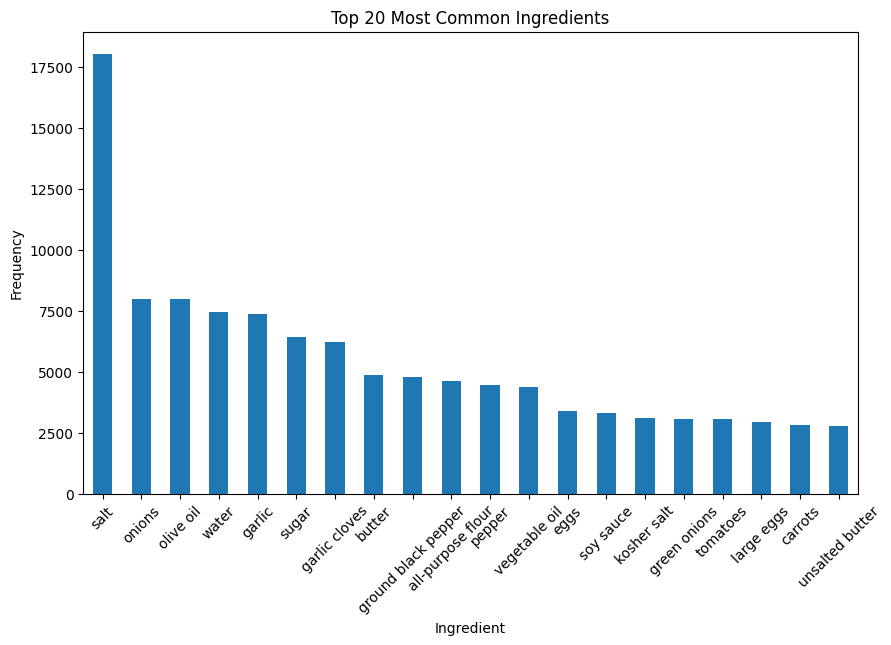


Number of ingredients that appear only once: 1759


In [ ]:
# Flatten all ingredients into a list
all_ingredients = [ingredient for recipe in train_df['ingredients'] for ingredient in recipe]

# Count frequencies
ingredient_counter = Counter(all_ingredients)

# Top 20 most common ingredients
top_ingredients = pd.DataFrame(ingredient_counter.most_common(20),
                               columns=["Ingredient", "Count"])
print(top_ingredients)

# Plot top 20
plt.figure(figsize=(10,6))
top_ingredients.set_index("Ingredient")["Count"].plot(kind="bar")
plt.title("Top 20 Most Common Ingredients")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# Rare ingredients (appear only once)
rare_ingredients = [ing for ing, count in ingredient_counter.items() if count == 1]
print(f"\nNumber of ingredients that appear only once: {len(rare_ingredients)}")

Existem outliers quando verificamos a quantidade de ingredientes por receita, para a baseline é interessante treinar o modelo sem remove-los, mas podemos testar remover parte dos exemplos ou parte dos ingredientes dos exemplos posteriormente para verificar se a acurácia melhora.

Summary statistics for number of ingredients per recipe:
count    39774.000000
mean        10.767713
std          4.428978
min          1.000000
25%          8.000000
50%         10.000000
75%         13.000000
max         65.000000
Name: num_ingredients, dtype: float64


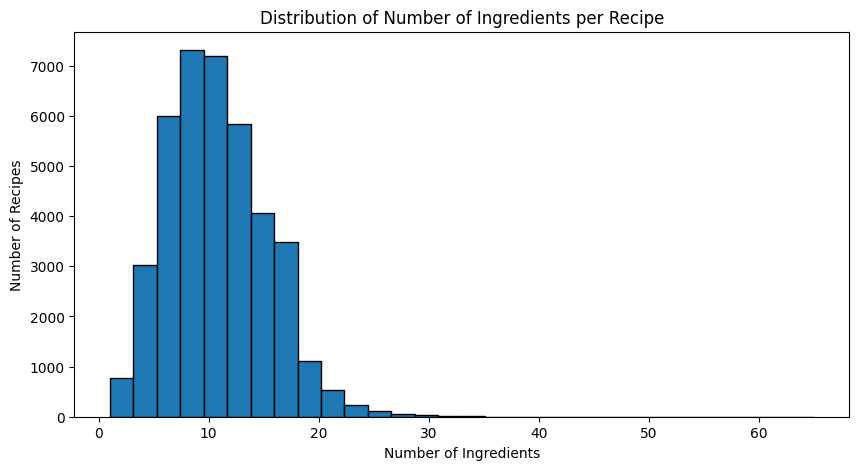

In [ ]:
train_df['num_ingredients'] = train_df['ingredients'].apply(len)
test_df['num_ingredients']  = test_df['ingredients'].apply(len)

print("Summary statistics for number of ingredients per recipe:")
print(train_df['num_ingredients'].describe())

plt.figure(figsize=(10,5))
plt.hist(train_df['num_ingredients'], bins=30, edgecolor='black')
plt.title("Distribution of Number of Ingredients per Recipe")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Recipes")
plt.show()

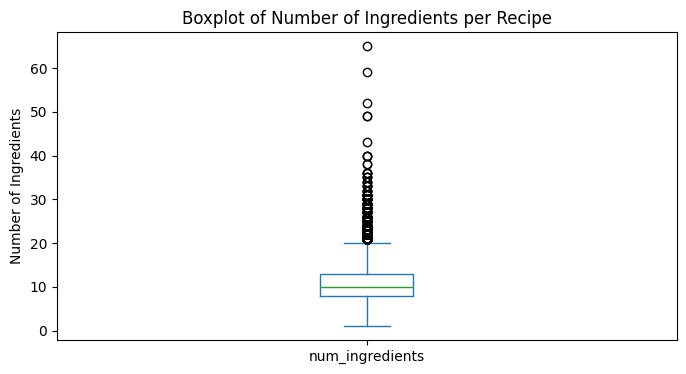


Número de outliers (pela regra 1.5*IQR): 1004
Limite inferior: 0.5, limite superior: 20.5
Exemplos de outliers:
         id      cuisine  num_ingredients
55    3535     jamaican               22
71   45839       indian               22
251   6862       indian               24
294   9829     filipino               38
342  20039      chinese               21
345  45039         thai               40
374  15171      chinese               21
408  34240      british               23
416  17658        greek               21
468  30327  southern_us               21


In [ ]:
# Boxplot
plt.figure(figsize=(8,4))
train_df['num_ingredients'].plot(kind='box')
plt.title("Boxplot of Number of Ingredients per Recipe")
plt.ylabel("Number of Ingredients")
plt.show()

# --- Outlier detection ---
Q1 = train_df['num_ingredients'].quantile(0.25)
Q3 = train_df['num_ingredients'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train_df[(train_df['num_ingredients'] < lower_bound) | (train_df['num_ingredients'] > upper_bound)]

print(f"\nNúmero de outliers (pela regra 1.5*IQR): {outliers.shape[0]}")
print(f"Limite inferior: {lower_bound}, limite superior: {upper_bound}")
print("Exemplos de outliers:\n", outliers[['id','cuisine','num_ingredients']].head(10))

Algumas cozinhas possuem mais ingredientes que outras, talvez valha a pena explorar essa informação durante o treinamento dos modelos.


Average number of ingredients per cuisine:
 cuisine
moroccan        12.909866
indian          12.705961
vietnamese      12.675152
cajun_creole    12.617076
thai            12.545809
jamaican        12.214829
chinese         11.982791
korean          11.284337
mexican         10.877446
spanish         10.423660
russian         10.224949
greek           10.182128
filipino        10.000000
italian          9.909033
french           9.817838
japanese         9.735067
british          9.708955
southern_us      9.634954
brazilian        9.520343
irish            9.299850
Name: num_ingredients, dtype: float64


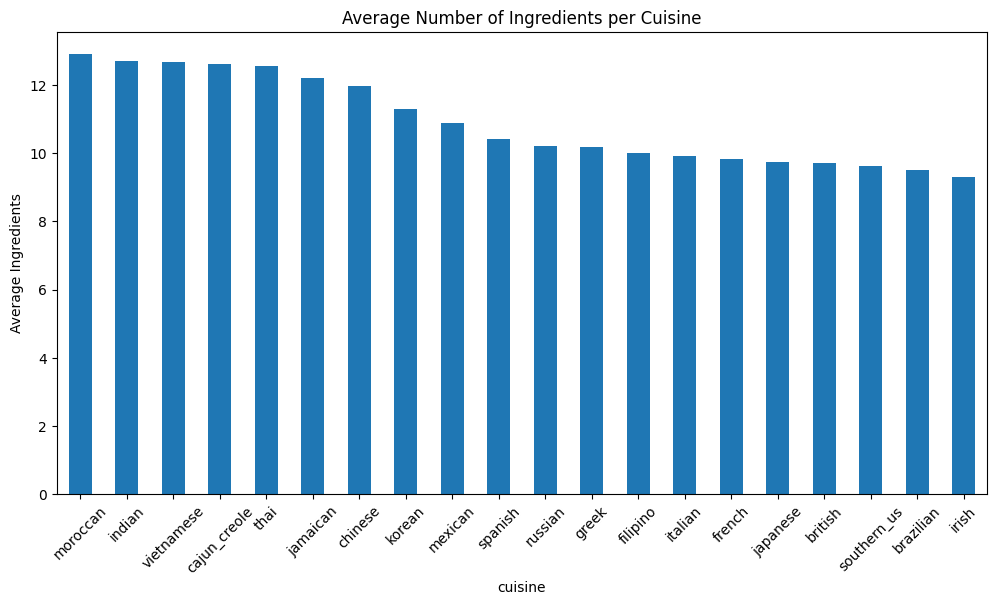

In [ ]:
# Average number of ingredients per cuisine
avg_per_cuisine = train_df.groupby("cuisine")['num_ingredients'].mean().sort_values(ascending=False)
print("\nAverage number of ingredients per cuisine:\n", avg_per_cuisine)

# Plot average per cuisine
plt.figure(figsize=(12,6))
avg_per_cuisine.plot(kind="bar")
plt.title("Average Number of Ingredients per Cuisine")
plt.ylabel("Average Ingredients")
plt.xticks(rotation=45)
plt.show()

# Limpeza e Pre-processamento

Convertendo ingredientes para snake case para padroniza-los.

In [ ]:
def clean_ingredient(ingredient: str) -> str:
    ingredient = ingredient.lower()
    ingredient = re.sub(r"[^a-z0-9]+", " ", ingredient)
    ingredient = ingredient.strip()
    ingredient = ingredient.replace(" ", "_")
    return ingredient

train_df['ingredients'] = train_df['ingredients'].apply(lambda ingr_list: [clean_ingredient(ing) for ing in ingr_list])
test_df['ingredients']  = test_df['ingredients'].apply(lambda ingr_list: [clean_ingredient(ing) for ing in ingr_list])

train_df.head(3)

,id,cuisine,ingredients,num_ingredients
0,10259,greek,"[romaine_lettuce, black_olives, grape_tomatoes...",9
1,25693,southern_us,"[plain_flour, ground_pepper, salt, tomatoes, g...",11
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking_oil, g...",12


No início foi testado a quantidade de ingredientes únicos, aqui eu testo denovo após a limpeza e percebo que já houve uma diminuição (6714 -> 6679)

In [ ]:
all_ingredients = {ingredient for recipe in train_df['ingredients'] for ingredient in recipe}
unique_ingredients = len(all_ingredients)

print("\nUnique ingredients across all recipes:", unique_ingredients)


Unique ingredients across all recipes: 6694


Removendo duplicatas.

In [ ]:
# Check duplicate IDs
print("Duplicate IDs in train:", train_df['id'].duplicated().sum())

# Convert list → tuple for duplicate detection
train_df['ingredients_tuple'] = train_df['ingredients'].apply(tuple)

# Check duplicate ingredient lists
dup_mask = train_df.duplicated(subset=['cuisine', 'ingredients_tuple'], keep=False)
duplicates = train_df[dup_mask].sort_values(by=['cuisine', 'ingredients_tuple'])

print("Duplicate ingredient lists:", dup_mask.sum())
print("\nDuplicate rows:")
print(duplicates[['id', 'cuisine', 'ingredients']].head(20))  # show first 20 for preview

# Drop duplicates if needed
train_df = train_df.drop_duplicates(subset=['cuisine', 'ingredients_tuple']).drop(columns=['ingredients_tuple'])


Duplicate IDs in train: 0
Duplicate ingredient lists: 190

Duplicate rows:
          id       cuisine                                        ingredients
1820    5337     brazilian  [cold_water, lime, sugar, sweetened_condensed_...
20314  10254     brazilian  [cold_water, lime, sugar, sweetened_condensed_...
34355   6460     brazilian  [cold_water, lime, sugar, sweetened_condensed_...
2944   26771     brazilian  [dried_black_beans, bacon_slices, pork_shoulde...
29353  17086     brazilian  [dried_black_beans, bacon_slices, pork_shoulde...
3574    4828     brazilian  [sugar, ice, lime, water, sweetened_condensed_...
30080  34573     brazilian  [sugar, ice, lime, water, sweetened_condensed_...
740    26463       british  [sugar, peeled_fresh_ginger, all_purpose_flour...
10201  27635       british  [sugar, peeled_fresh_ginger, all_purpose_flour...
10365  15276  cajun_creole  [capers, salt, fat_free_mayonnaise, cooking_sp...
30156  38131  cajun_creole  [capers, salt, fat_free_mayonnaise, coo

Removendo inconsistências.

In [ ]:
print("Duplicate IDs in train:", train_df['id'].duplicated().sum())

train_df['ingredients_tuple'] = train_df['ingredients'].apply(tuple)

grouped = train_df.groupby('ingredients_tuple')

cross_cuisine_dups = grouped.filter(lambda g: g['cuisine'].nunique() > 1)

print("Número de receitas com mesma lista de ingredientes mas cuisine diferente:", cross_cuisine_dups.shape[0])

print("\nExemplos de duplicatas cross-cuisine:")
print(cross_cuisine_dups[['id', 'cuisine', 'ingredients']].head(20))

train_df = train_df.drop(cross_cuisine_dups.index).drop(columns=['ingredients_tuple'])

Duplicate IDs in train: 0
Número de receitas com mesma lista de ingredientes mas cuisine diferente: 6

Exemplos de duplicatas cross-cuisine:
          id  cuisine                                        ingredients
8990   41124   indian                                           [butter]
20472  21949   french                       [buttermilk, whipping_cream]
20880   9397  spanish  [water, fresh_lime_juice, boneless_pork_should...
22119  41135   french                                           [butter]
25411  42055  mexican                       [buttermilk, whipping_cream]
34313  43476  mexican  [water, fresh_lime_juice, boneless_pork_should...


Abaixo podemos verificar que existem palavras diferentes que representam o mesmo tipo de ingrediente, sendo assim teremos dois caminhos possíveis:
- Usar algum método para corrigir os dados como lematização ou stemming, permitindo o uso de vetorizadores simples como o TF-IDF
- Usar métodos baseados em embeddings que lidam bem com pequenas variações como o Word2Vec

In [ ]:
# Lista de todos os ingredientes únicos
unique_ingredients = set(ing for recipe in train_df['ingredients'] for ing in recipe)

# Contagem de frequência (só por conferência)
ingredient_counts = Counter([ing for recipe in train_df['ingredients'] for ing in recipe])

print(f"Número de ingredientes únicos: {len(unique_ingredients)}")

# Função para sugerir similares usando SequenceMatcher
def find_similar_words(word, vocab, cutoff=0.85):
    return difflib.get_close_matches(word, vocab, n=5, cutoff=cutoff)

# Checar alguns exemplos (os mais comuns)
for ing, _ in ingredient_counts.most_common(50):
    similars = find_similar_words(ing, unique_ingredients, cutoff=0.9)
    if len(similars) > 1:
        print(f"{ing} -> {similars}")


Número de ingredientes únicos: 6694
unsalted_butter -> ['unsalted_butter', 'salted_butter']
black_pepper -> ['black_pepper', 'blackpepper']
chili_powder -> ['chili_powder', 'chile_powder']
diced_tomatoes -> ['diced_tomatoes', 'dried_tomatoes']


# Feature Engineering

Abaixo são geradas as códificações das features e da variável alvo para serem usadas no treinamento do modelo. São exploradas várias formas de representação que ainda serão analisadas antes de escolhermos o método final.

In [ ]:
train_texts = [" ".join(ings) for ings in train_df['ingredients']]
test_texts  = [" ".join(ings) for ings in test_df['ingredients']]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b", binary=True)
X_train = vectorizer.fit_transform(train_texts)
X_test  = vectorizer.transform(test_texts)

print("Shape of training matrix:", X_train.shape)
print("Shape of test matrix:", X_test.shape)

print("Number of unique ingredients (features):", len(vectorizer.get_feature_names_out()))

Shape of training matrix: (39671, 6694)
Shape of test matrix: (9944, 6694)
Number of unique ingredients (features): 6694


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
X_train_tfidf = tfidf_vectorizer.fit_transform(train_texts)
X_test_tfidf  = tfidf_vectorizer.transform(test_texts)

print("Shape of TF-IDF training matrix:", X_train_tfidf.shape)

Shape of TF-IDF training matrix: (39671, 6694)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(train_df['cuisine'])

print("Classes:", le.classes_)
print("Encoded example:", y[:10])

Classes: ['brazilian' 'british' 'cajun_creole' 'chinese' 'filipino' 'french'
 'greek' 'indian' 'irish' 'italian' 'jamaican' 'japanese' 'korean'
 'mexican' 'moroccan' 'russian' 'southern_us' 'spanish' 'thai'
 'vietnamese']
Encoded example: [ 6 16  4  7  7 10 17  9 13  9]


In [ ]:
# 1. Preparar os dados como listas de tokens (já temos ingredients em snake_case)
train_tokens = train_df['ingredients'].tolist()
test_tokens  = test_df['ingredients'].tolist()

# 2. Treinar modelo Word2Vec no corpus de ingredientes
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=300,   # tamanho do embedding (pode ajustar: 50, 100, 300…)
    window=10,
    min_count=1,       # inclui até ingredientes raros
    workers=5,
    sg=1               # 1 = skip-gram, 0 = CBOW
)

# 3. Função para transformar lista de ingredientes em vetor médio
def recipe_vector(tokens, model, vector_size=300):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)  # fallback se não encontrar nenhum token
    return np.mean(vectors, axis=0)

# 4. Criar matrizes para treino e teste
X_train_w2v = np.array([recipe_vector(recipe, w2v_model, 300) for recipe in train_tokens])
X_test_w2v  = np.array([recipe_vector(recipe, w2v_model, 300) for recipe in test_tokens])

print("Shape of Word2Vec training matrix:", X_train_w2v.shape)
print("Shape of Word2Vec test matrix:", X_test_w2v.shape)

Shape of Word2Vec training matrix: (39671, 300)
Shape of Word2Vec test matrix: (9944, 300)


Ainda é possivel concatenar aos vetores de treino e teste a informação do número de ingredientes na receita, que pode ser relevante. Mas para uma baseline pode ser feito sem.

In [ ]:
# Feature adicional
num_ingr_train = train_df[['num_ingredients']].values
num_ingr_test  = test_df[['num_ingredients']].values

# Concatenar com a matriz TF-IDF
X_train_v2 = hstack([X_train_tfidf, num_ingr_train])
X_test_v2  = hstack([X_test_tfidf, num_ingr_test])

print("Formato final da matriz:", X_train_v2.shape)

Formato final da matriz: (39671, 6695)


# Plano de Projeto

## Plano de Projeto – What’s Cooking?

Com base na análise inicial do dataset, elaboramos o seguinte plano de execução para o desenvolvimento do modelo preditivo.

---

## 1. Entendimento dos Dados
A análise exploratória mostrou que:  

- Cada registro representa uma **receita**, identificada por um `id`, associada a uma **cuisine** (variável alvo) e a uma lista de **ingredients**.  
- O dataset de treino contém cerca de **40 mil receitas** e o de teste cerca de **10 mil**.  
- Existem aproximadamente **6 a 7 mil ingredientes únicos**, mas com forte **desbalanceamento de frequência** (alguns muito comuns como `salt`, outros raríssimos).  
- A variável alvo (`cuisine`) é **multiclasse**, com mais de 20 categoria e apresenta desbalanceamento.  
- Há **outliers em número de ingredientes por receita** (média ≈ 10, mas casos com até 60+).  

---

## 2. Pré-processamento

As etapas previstas são:

- **Normalização de texto**:
  - Conversão para **snake_case**;
  - Avaliação da necessidade de usar métodos de correção de palavras com pequenas variações (`chili_powder` vs `chile_powder`).
- **Tratamento de duplicatas e inconsistências**:
  - Exclusão de duplicatas que não agregam informação.
  - Exclusão de registros inconsistentes com mesma lista de ingredientes em mais de uma cuisine (6 casos identificados).
- **Outliers**:
  - Monitoramento de receitas com número muito alto de ingredientes (não remover a princípio, apenas avaliar impacto).
- **Representação dos dados**:
  - Testar diferentes formas de vetorização:
    - **Bag-of-Words (BoW)** binário;
    - **TF-IDF** (peso maior para ingredientes raros);
    - **Word2Vec / FastText embeddings** (capturar semântica, lidar com variações leves de escrita).
  - Testar a inclusão ou não da informação de quantidade de ingredientes junto dos vetores gerados.

---

## 3. Balanceamento das Classes

- Algumas cozinhas têm menos exemplos.  
- Estratégias possíveis:
  - Ajuste de **class weights** em modelos lineares/árvores;
  - Validação estratificada para garantir representação justa.

---

## 4. Modelagem

Modelos candidatos:  

- **Modelos simples**:  
  - Naive Bayes (tradicional em classificação de texto);  
  - Logistic Regression com BoW/TF-IDF.
- **Modelos mais avançados**:  
  - **Random Forest / XGBoost / LightGBM** sobre vetores esparsos;  
  - **Redes neurais simples (MLP)** sobre embeddings densos;  
  - Possível exploração de **FastText embeddings** para robustez.  

Etapas:  
- Comparar modelos simples vs modelos mais complexos.  
- Ajustar hiperparâmetros (grid search / random search).  
- Usar validação cruzada estratificada.  

---

## 5. Geração de Predições

- Aplicar o modelo final ao `test.json`.  
- Gerar `submission.csv` no formato requerido:  

| id   | cuisine   |  
|------|-----------|  
| 10259 | greek     |  
| 25693 | southern  |  
| ...   | ...       |  

---

## 6. Avaliação de Desempenho e Melhorias

- Métrica oficial: **accuracy** (proporção de predições corretas).  
- Acompanhar também métricas por classe (confusion matrix, F1-score macro) para evitar viés contra classes menores.  
- Iterar com técnicas de:
  - Redução de dimensionalidade (PCA, SVD para TF-IDF);  
  - Feature selection (descartar ingredientes extremamente raros);  
  - Ensemble de modelos.  

---

## 7. Dificuldades e Riscos Previstos

- **Alta dimensionalidade**: muitos ingredientes únicos → matriz muito esparsa.  
- **Variações ortográficas/sinônimos** podem diluir informação (ex.: `chili_powder` vs `chile_powder`).  
- **Cozinhas similares** (caso existam) podem ser difíceis de diferenciar.  
- **Outliers no tamanho da receita** podem gerar ruído.  

Apesar disso, o dataset é limpo, bem estruturado e adequado para experimentos em NLP e classificação multiclasse.


# Modelagem TF-IDF

Após as etapas de pré-processamento e engenharia de atributos, inicia-se a fase de **modelagem**, cujo objetivo é construir classificadores capazes de prever corretamente a **cozinha** (`cuisine`) associada a cada receita, com base em seus **ingredientes**.

Trata-se de um problema de **classificação multiclasse**, contendo mais de 20 categorias distintas e um forte **desbalanceamento entre as classes**.  
Para representar o texto de forma numérica, utilizamos a técnica de **TF-IDF (Term Frequency-Inverse Document Frequency)**.

Nesta etapa:

- Cada lista de ingredientes é convertida em uma **string única por receita**.  
- As classes (`cuisine`) são codificadas numericamente através de `LabelEncoder`.  
- O texto é transformado em uma matriz **TF-IDF de unigramas e bigramas**, com remoção de termos muito raros (`min_df=2`) e muito frequentes (`max_df=0.90`).  
- Também é incorporada uma variável numérica representando o **número de ingredientes por receita**, normalizada entre 0 e 1.  
- Por fim, ambas as representações (TF-IDF + feature numérica) são **concatenadas** para formar a matriz final de entrada do modelo.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from scipy.sparse import hstack, csr_matrix

train_texts = [" ".join(ings) for ings in train_df["ingredients"]]
test_texts  = [" ".join(ings) for ings in test_df["ingredients"]]

le = LabelEncoder()
y = le.fit_transform(train_df["cuisine"])

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,             #termos raros
    max_df=0.90,          #termos muito frequente
    sublinear_tf=True
)

X_tr_tfidf = tfidf.fit_transform(train_texts)

scaler = MinMaxScaler()
num_tr_scaled = scaler.fit_transform(train_df[["num_ingredients"]])

X_train_v2 = hstack([X_tr_tfidf, csr_matrix(num_tr_scaled)])

print("Shape de X_train_v2:", X_train_v2.shape)

Shape de X_train_v2: (39671, 53263)


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = LinearSVC(C=2.0)

scores = cross_val_score(svm, X_train_v2, y, cv=cv, scoring="accuracy", n_jobs=-1)
print("Acurácias por fold:", scores)
print("Acurácia média    :", scores.mean())

Shape de X_train_v2: (39671, 53263)
Acurácias por fold: [0.76698173 0.76922107 0.76997731 0.76733048 0.76493572]
Acurácia média    : 0.7676892618672415


## Vetorização Avançada (Word + Char N-grams)

Nesta etapa, decidimos enriquecer a representação dos dados combinando informações léxicas em dois níveis:

- **TF-IDF de palavras** (1–2 n-grams): captura combinações frequentes de ingredientes como "olive oil", "soy sauce", etc.
- **TF-IDF de caracteres** (3–5 n-grams): captura partes de palavras, erros ortográficos, formas similares e variações menores como `"chili"` vs `"chile"`.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from scipy.sparse import hstack, csr_matrix

train_texts = [" ".join(ings) for ings in train_df["ingredients"]]
y = le.fit_transform(train_df["cuisine"])

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
    strip_accents="unicode",
    token_pattern=r"(?u)\b[a-z_]+\b"
)
X_word = word_vectorizer.fit_transform(train_texts)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,5),
    min_df=3,
    max_df=0.90,
    sublinear_tf=True
)
X_char = char_vectorizer.fit_transform(train_texts)

scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(train_df[["num_ingredients"]])
num_block  = csr_matrix(num_scaled)

X_final = hstack([
    X_word * 1.0,
    X_char * 1.2,
    num_block * 0.5
])

print("Shape final:", X_final.shape)

Shape final: (39671, 108123)


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm = LinearSVC(C=0.3)
scores = cross_val_score(svm, X_final, y, cv=cv, scoring="accuracy", n_jobs=-1)

print("Acurácias por fold:", scores)
print("Acurácia média    :", scores.mean())

Acurácias por fold: [0.79886578 0.79253844 0.79531132 0.79153012 0.79203428]
Acurácia média    : 0.7940559902751575


## Ensemble com VotingClassifier
Com base no bom desempenho individual do `LinearSVC` e da `LogisticRegression`, construímos um ensemble combinando ambos os modelos para melhorar ainda mais a estabilidade e a performance.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC

svc = LinearSVC(C=0.3)
logreg = LogisticRegression(C=4.0, solver='saga', max_iter=3000, n_jobs=-1)

ensemble = VotingClassifier(
    estimators=[
        ('svc', svc),
        ('logreg', logreg)
    ],
    voting='hard',
    n_jobs=-1
)

scores = cross_val_score(ensemble, X_final, y, cv=5, scoring='accuracy', n_jobs=-1)
print("Accuracies por fold:", scores)
print("Accuracy média     :", scores.mean())

Accuracies por fold: [0.7942029  0.79871439 0.79316864 0.79140408 0.80249559]
Accuracy média     : 0.7959971211772485


## Redução de dimensionalidade
Após alcançar uma performance sólida com o ensemble de modelos lineares (`LinearSVC` + `LogisticRegression`), buscamos otimizar a generalização e reduzir o custo computacional utilizando uma técnica de seleção de atributos.

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(score_func=chi2, k=30000)
X_selected = selector.fit_transform(X_final, y)

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

ensemble = VotingClassifier(
    estimators=[
        ('svc', LinearSVC(C=0.3)),
        ('logreg', LogisticRegression(C=4.0, solver='saga', max_iter=3000, n_jobs=-1))
    ],
    voting='hard',
    n_jobs=-1
)

scores = cross_val_score(ensemble, X_selected, y, cv=5, scoring="accuracy", n_jobs=-1)
print("Accuracies com SelectKBest:", scores)
print("Accuracy média:", scores.mean())

Accuracies com SelectKBest: [0.79319471 0.80110915 0.7955634  0.79216032 0.80615074]
Accuracy média: 0.7976356643633226


## Ensemble com votação *soft*
Para explorar ganhos adicionais de desempenho e estabilidade, adotamos um ensemble com **votação probabilística (*soft*)**. Diferente da votação *hard* (maioria simples), a votação *soft* combina as **probabilidades** previstas por cada modelo, permitindo decisões mais calibradas — especialmente úteis quando classes são próximas.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

base_svc = LinearSVC(C=0.3)
cal_svc = CalibratedClassifierCV(base_svc, cv=3)

logreg = LogisticRegression(C=4.0, solver='saga', max_iter=3000, n_jobs=-1)

soft_ensemble = VotingClassifier(
    estimators=[
        ('cal_svc', cal_svc),
        ('logreg', logreg)
    ],
    voting='soft',
    n_jobs=-1
)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(soft_ensemble, X_selected, y, cv=cv, scoring='accuracy', n_jobs=-1)

print("Accuracies por fold:", scores)
print("Accuracy média     :", scores.mean())

Accuracies por fold: [0.80718336 0.80110915 0.79934459 0.79720192 0.79707588]
Accuracy média     : 0.8003829800008864


## Grid Search
Após a construção da matriz TF-IDF e a definição dos modelos base,  
foi realizada uma etapa de **busca em grade (Grid Search)** com validação para encontrar os valores ideais dos hiperparâmetros do classificador principal.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svc = LinearSVC(max_iter=5000, dual=True)
grid_svc = GridSearchCV(
    svc,
    param_grid={"C": [0.1, 0.3, 0.5, 1.0]},
    scoring="accuracy", cv=cv, n_jobs=-1, verbose=1
)
grid_svc.fit(X_selected, y)
best_C_svc = grid_svc.best_params_["C"]

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [ ]:
print(best_C_svc)

0.3


In [ ]:
svc_best = LinearSVC(C=best_C_svc, max_iter=5000, dual=True)
cal_methods = ["sigmoid", "isotonic"]
cal_scores = {}
for m in cal_methods:
    cal = CalibratedClassifierCV(estimator=svc_best, cv=3, method=m)
    sc = cross_val_score(cal, X_selected, y, cv=cv, scoring="accuracy", n_jobs=-1)
    cal_scores[m] = (sc.mean(), sc)
best_method = max(cal_scores, key=lambda k: cal_scores[k][0])
cal_svc = CalibratedClassifierCV(estimator=svc_best, cv=3, method=best_method)

In [ ]:
print(best_method)

sigmoid


In [ ]:
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=3000, n_jobs=-1),
    param_grid={
        "C": [1.0, 2.0, 4.0],
        "solver": ["liblinear", "saga"]
    },
    scoring="accuracy", cv=cv, n_jobs=-1, verbose=1
)
grid_lr.fit(X_selected, y)
best_lr = grid_lr.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


In [ ]:
print(best_lr)

LogisticRegression(C=4.0, max_iter=3000, n_jobs=-1, solver='liblinear')


In [ ]:
weights_grid = [(1,1), (2,1), (1,2), (3,1), (1,3)]
ens_scores = []
for w in weights_grid:
    ens = VotingClassifier(
        estimators=[("cal_svc", cal_svc), ("logreg", best_lr)],
        voting="soft", weights=w, n_jobs=-1
    )
    sc = cross_val_score(ens, X_selected, y, cv=cv, scoring="accuracy", n_jobs=-1)
    ens_scores.append((w, sc.mean(), sc))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
print(max(ens_scores))

((3, 1), 0.8007359328194212, array([0.80554505, 0.80098311, 0.80073103, 0.79858835, 0.79783211]))


In [ ]:
best_w, best_mean, best_folds = max(ens_scores, key=lambda t: t[1])
print("Mejor SVC C:", best_C_svc, "| Mejor método calib:", best_method)
print("Mejor LogReg:", grid_lr.best_params_)
print("Mejor pesos ensemble:", best_w, "| acc media:", round(best_mean,5), "| folds:", np.round(best_folds,5))

Mejor SVC C: 0.3 | Mejor método calib: sigmoid
Mejor LogReg: {'C': 4.0, 'solver': 'liblinear'}
Mejor pesos ensemble: (3, 1) | acc media: 0.80074 | folds: [0.80555 0.80098 0.80073 0.79859 0.79783]


In [ ]:
final_ensemble = VotingClassifier(
    estimators=[("cal_svc", cal_svc), ("logreg", best_lr)],
    voting="soft", weights=best_w, n_jobs=-1
)

# Submission

In [ ]:
X_word_test = word_vectorizer.transform(test_texts)
X_char_test = char_vectorizer.transform(test_texts)

num_test_scaled = scaler.transform(test_df[["num_ingredients"]])
num_test_block  = csr_matrix(num_test_scaled)

X_test_final = hstack([
    X_word_test * 1.0,
    X_char_test * 1.2,
    num_test_block * 0.5
])

X_train_selected = selector.transform(X_final)
X_test_selected  = selector.transform(X_test_final)

final_ensemble.fit(X_train_selected, y)

y_test_pred = final_ensemble.predict(X_test_selected)
cuisine_pred = le.inverse_transform(y_test_pred)

submission = pd.DataFrame({
    "id": test_df["id"],
    "cuisine": cuisine_pred
})

submission.to_csv("submission_soft_ensemble.csv", index=False)

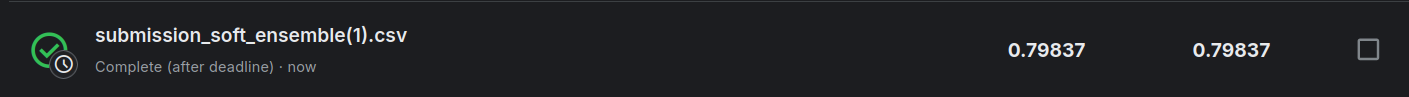